# Hydrogen Bond Lifetime Survival Analysis

This notebook analyzes hydrogen bond **binding event lifetimes** and plots **survival curves**.

## Survival Analysis Approach

**What we measure:**
- Extract continuous binding events from H-bond time series
- Calculate duration (lifetime) of each event
- Plot survival curves: P(lifetime > t) vs time

**Censoring:**
- **Left-censored**: Bond exists at first analyzed frame (start unknown)
- **Right-censored**: Bond exists at last analyzed frame (end unknown)
- Both types are **discarded** to avoid bias

**Clone aggregation:**
- All binding events are pooled across clones for each system
- This provides better statistics for survival curve estimation

**Data source:** `/data/hbond-atom/` (atom-level H-bond matrices)

In [291]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from scipy import stats
from scipy.optimize import curve_fit
from scipy.spatial.distance import jensenshannon
import warnings

# Set plotting style
#sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

## Configuration

In [292]:
# Data directory
DATA_DIR = Path('../data/hbond-atom')

# Analysis parameters
ANALYSIS_START_FRAME = 13000   # Start of production analysis window
ANALYSIS_END_FRAME = 23000     # End of production analysis window
GAP_TOLERANCE = 0              # Frames to bridge gaps (0 = no bridging)
TIME_PER_FRAME_NS = 0.1        # 100 ps = 0.1 ns per frame

# Residue grouping by dataset (residue number ranges)
RESIDUE_GROUPS = {
    '20251112': {
        'eIF5': (844, 849),
        'tRNAi': (1911, 1914),
        'mRNA': (1960, 1962),
        'rRNA': (2425, 2426)
    }
}

# Color scheme for groups (used for title coloring)
GROUP_COLORS = {
    'eIF5': '#8d2788',      # Purple
    'tRNAi': '#23b24b',     # Green
    'mRNA': '#dc7bbb',      # Pink
    'rRNA': '#4994d0',      # Blue
    'Unknown': '#888888'    # Gray
}

# System definitions
SYSTEMS = [
    '20251112_eIF5wt_AUG', '20251112_eIF5wt_ACG', '20251112_eIF5wt_CUG', '20251112_eIF5wt_GUG',
    '20251112_eIF5wt_UUG', '20251112_eIF5wt_AUC',
    '20251112_eIF5_N30K_AUG', '20251112_eIF5_N30Q_AUG', '20251112_eIF5_G29A_G31A_AUG'
]

SYSTEM_LABELS = {
    '20251112_eIF5wt_AUG': 'wt/AUG',
    '20251112_eIF5wt_ACG': 'wt/ACG',
    '20251112_eIF5wt_CUG': 'wt/CUG',
    '20251112_eIF5wt_UUG': 'wt/UUG',
    '20251112_eIF5wt_AUC': 'wt/AUC',
    '20251112_eIF5_N30K_AUG': 'N30K/AUG',
    '20251112_eIF5_N30Q_AUG': 'N30Q/AUG',
    '20251112_eIF5_G29A_G31A_AUG': 'G29A_G31A/AUG'
}

# Color palette for systems
SYSTEM_COLORS = {
    '20251112_eIF5wt_AUG': '#002849',
    '20251112_eIF5wt_ACG': '#6daa48',
    '20251112_eIF5wt_CUG': '#2ba7d8',
    '20251112_eIF5wt_UUG': '#6a3a74',
    '20251112_eIF5wt_AUC': '#faa41a',
    '20251112_eIF5_N30K_AUG': '#067f92',
    '20251112_eIF5_N30Q_AUG': '#3954a4',
    '20251112_eIF5_G29A_G31A_AUG': '#f37039'
}

## Data Loading Functions

In [304]:
def parse_filename(filename: str) -> Optional[Dict[str, str]]:
    """
    Parse filename to extract system information.
    
    Example: 20251112_48S_eIF5wt_AUG_clone0-HB_N30-matrix_atom.dat
    
    Returns:
        Dictionary with date, variant, codon, clone, system keys
    """
    pattern = r'(\d{8})_48S_(eIF5.*?)_(AUG|ACG|CUG|UUG|AUC|GUG)_clone(\d+)-HB_N30-matrix_atom\.dat'
    match = re.match(pattern, filename)
    
    if match:
        return {
            'date': match.group(1),
            'variant': match.group(2),
            'codon': match.group(3),
            'clone': match.group(4),
            'system': f"{match.group(1)}_{match.group(2)}_{match.group(3)}"
        }
    return None

In [294]:
def extract_residue_number(atom_name: str) -> int:
    """
    Extract residue number from atom name.
    
    Examples:
        'A_1911@H2' -> 1911
        'GLY_845@O' -> 845
        'U_1912@O2' -> 1912
    
    Args:
        atom_name: Full atom identifier from column header
    
    Returns:
        Integer residue number, or 0 if not found
    """
    match = re.search(r'_(\d+)@', atom_name)
    return int(match.group(1)) if match else 0

In [295]:
def get_molecule_group(atom_name: str, date: str) -> str:
    """
    Map an atom name to its molecule group based on residue number.
    
    Args:
        atom_name: e.g., 'U_1912@O2', 'GLY_845@O'
        date: Dataset identifier ('20251112')
    
    Returns:
        Group name ('eIF5', 'tRNAi', 'mRNA', 'rRNA', or 'Unknown')
    """
    res_num = extract_residue_number(atom_name)
    if res_num == 0:
        return 'Unknown'
    
    groups = RESIDUE_GROUPS.get(date, {})
    for group_name, (start, end) in groups.items():
        if start <= res_num <= end:
            return group_name
    
    return 'Unknown'

In [296]:
def load_atom_matrix(filepath: Path) -> Tuple[np.ndarray, List[str], Dict[str, str]]:
    """
    Load an atom-level H-bond matrix file.
    
    Returns:
        matrix: 2D array (frames x atoms) of H-bond counts
        atom_names: List of atom column names
        info: Parsed filename information
    """
    info = parse_filename(filepath.name)
    if info is None:
        raise ValueError(f"Could not parse filename: {filepath.name}")
    
    with open(filepath, 'r') as f:
        header = f.readline().strip()
    
    # Split by whitespace (tabs or spaces), skip '#Frame'
    atom_names = header.split()[1:]
    
    data = np.loadtxt(filepath, skiprows=1)
    matrix = data[:, 1:].astype(int)  # Skip frame column
    
    return matrix, atom_names, info

## Lifetime Extraction Functions

In [297]:
def extract_binding_events(
    time_series: np.ndarray,
    gap_tolerance: int = 0
) -> List[Tuple[int, int, bool, bool]]:
    """
    Extract continuous binding events from binary time series.
    
    A binding event is a contiguous stretch where H-bond count >= 1.
    
    Args:
        time_series: 1D array of H-bond counts per frame
        gap_tolerance: Number of frames to bridge gaps (0 = no bridging)
    
    Returns:
        List of (start_frame, end_frame, left_censored, right_censored)
        - start_frame: First frame of binding event (0-indexed)
        - end_frame: Last frame of binding event (inclusive)
        - left_censored: True if event starts at frame 0
        - right_censored: True if event ends at last frame
    """
    events: List[Tuple[int, int, bool, bool]] = []
    n = len(time_series)
    i = 0
    
    while i < n:
        if time_series[i] >= 1:  # Bond exists
            start = i
            # Find end of binding event
            while i < n and time_series[i] >= 1:
                i += 1
            end = i - 1  # Last frame with bond
            
            # Gap tolerance handling (for future extension)
            # For now, gap_tolerance = 0 means no bridging
            
            left_censored = (start == 0)
            right_censored = (end == n - 1)
            events.append((start, end, left_censored, right_censored))
        else:
            i += 1
    
    return events

In [298]:
def filter_complete_events(
    events: List[Tuple[int, int, bool, bool]]
) -> List[Tuple[int, int]]:
    """
    Remove censored events, keeping only complete observations.
    
    Args:
        events: List from extract_binding_events()
    
    Returns:
        List of (start_frame, end_frame) for complete events only
    """
    complete: List[Tuple[int, int]] = []
    for start, end, left_cens, right_cens in events:
        if not left_cens and not right_cens:
            complete.append((start, end))
    return complete

In [299]:
def calculate_lifetimes(
    complete_events: List[Tuple[int, int]]
) -> List[int]:
    """
    Convert complete binding events to lifetimes (in frames).
    
    Lifetime = end_frame - start_frame + 1 (inclusive count)
    
    Args:
        complete_events: List of (start_frame, end_frame)
    
    Returns:
        List of lifetimes in frames
    """
    return [end - start + 1 for start, end in complete_events]

## Survival Function Calculation

In [300]:
def calculate_survival_function(
    lifetimes: List[int],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate empirical survival function: S(t) = P(lifetime > t)
    
    Uses the complement of the empirical CDF (ECDF).
    S(t) = 1 - F(t) where F(t) is the proportion of events with lifetime <= t.
    
    Args:
        lifetimes: List of lifetimes in frames
        time_per_frame_ns: Conversion factor (ns per frame)
    
    Returns:
        time_points_ns: Array of time values in nanoseconds
        survival_probability: Array of S(t) values (monotonically decreasing)
    """
    if len(lifetimes) == 0:
        return np.array([0.0]), np.array([1.0])
    
    # Sort lifetimes
    sorted_lifetimes = np.sort(lifetimes)
    n = len(sorted_lifetimes)
    
    # Calculate survival at each unique lifetime
    unique_lifetimes = np.unique(sorted_lifetimes)
    
    # Start with S(0) = 1.0 (all events survive at t=0)
    time_points = [0]
    survival = [1.0]
    
    for t in unique_lifetimes:
        # S(t) = proportion with lifetime > t
        s_t = np.sum(sorted_lifetimes > t) / n
        time_points.append(t)
        survival.append(s_t)
    
    # Convert to nanoseconds
    time_points_ns = np.array(time_points) * time_per_frame_ns
    survival_probability = np.array(survival)
    
    return time_points_ns, survival_probability

In [301]:
def find_median_lifetime(
    time_points: np.ndarray,
    survival: np.ndarray
) -> Optional[float]:
    """
    Find median lifetime (time at 50% survival) by interpolation.
    
    Args:
        time_points: Array of time values (ns)
        survival: Array of survival probabilities
    
    Returns:
        Median lifetime in ns, or None if survival never drops below 0.5
    """
    if len(time_points) < 2:
        return None
    
    # Find where survival crosses 0.5
    for i in range(len(survival) - 1):
        if survival[i] >= 0.5 and survival[i + 1] < 0.5:
            # Linear interpolation
            t1, t2 = time_points[i], time_points[i + 1]
            s1, s2 = survival[i], survival[i + 1]
            median = t1 + (0.5 - s1) * (t2 - t1) / (s2 - s1)
            return median
    
    # Check if survival starts below 0.5
    if survival[0] < 0.5:
        return 0.0
    
    # Survival never drops below 0.5
    return None

In [302]:
def biexponential(
    t: np.ndarray,
    a1: float,
    tau1: float,
    a2: float,
    tau2: float
) -> np.ndarray:
    """
    Biexponential decay function for survival curve fitting.
    
    S(t) = a1 * exp(-t/tau1) + a2 * exp(-t/tau2)
    
    Args:
        t: Time values
        a1: Amplitude of fast component
        tau1: Time constant of fast component (ns)
        a2: Amplitude of slow component
        tau2: Time constant of slow component (ns)
    
    Returns:
        Survival probability at each time point
    """
    return a1 * np.exp(-t / tau1) + a2 * np.exp(-t / tau2)


def fit_biexponential(
    time_pts: np.ndarray,
    survival: np.ndarray,
    max_time: Optional[float] = None
) -> Optional[Dict]:
    """
    Fit biexponential decay to survival curve data.
    
    Args:
        time_pts: Time values in ns
        survival: Survival probabilities
        max_time: Maximum time to include in fit (ns)
    
    Returns:
        Dictionary with fit parameters, or None if fit fails:
        - 'a1', 'tau1': Fast component amplitude and time constant
        - 'a2', 'tau2': Slow component amplitude and time constant
        - 'params': Full parameter array [a1, tau1, a2, tau2]
        - 'pcov': Covariance matrix
        - 'r_squared': Goodness of fit
    """
    # Filter data
    if max_time is not None:
        mask = time_pts <= max_time
        time_pts = time_pts[mask]
        survival = survival[mask]
    
    # Need at least 5 points for 4 parameters
    if len(time_pts) < 5:
        return None
    
    # Skip t=0 point (always S=1) for better fitting
    if time_pts[0] == 0:
        time_pts = time_pts[1:]
        survival = survival[1:]
    
    if len(time_pts) < 5:
        return None
    
    try:
        # Initial guesses: split amplitude 50/50, guess time constants
        t_median = np.median(time_pts)
        p0 = [0.5, t_median * 0.3, 0.5, t_median * 2.0]
        
        # Bounds: amplitudes [0, 1], time constants [0.01, large]
        bounds = (
            [0.0, 0.01, 0.0, 0.01],      # Lower bounds
            [1.0, 1000.0, 1.0, 1000.0]    # Upper bounds
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                biexponential, time_pts, survival,
                p0=p0, bounds=bounds, maxfev=5000
            )
        
        # Calculate R-squared
        y_pred = biexponential(time_pts, *popt)
        ss_res = np.sum((survival - y_pred) ** 2)
        ss_tot = np.sum((survival - np.mean(survival)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Ensure tau1 < tau2 (tau1 is fast, tau2 is slow)
        if popt[1] > popt[3]:
            popt = [popt[2], popt[3], popt[0], popt[1]]
        
        return {
            'a1': popt[0],
            'tau1': popt[1],
            'a2': popt[2],
            'tau2': popt[3],
            'params': popt,
            'pcov': pcov,
            'r_squared': r_squared
        }
    except (RuntimeError, ValueError):
        return None

## Load Data and Process Lifetimes

In [305]:
# Load all atom matrix files and organize by system
all_files = sorted(DATA_DIR.glob('*-matrix_atom.dat'))
print(f"Found {len(all_files)} atom matrix files")

# Organize by system
systems_files: Dict[str, List[Path]] = {}
for filepath in all_files:
    info = parse_filename(filepath.name)
    if info is None:
        continue
    
    system_key = info['system']
    if system_key not in systems_files:
        systems_files[system_key] = []
    systems_files[system_key].append(filepath)

print(f"Organized into {len(systems_files)} unique systems")
for system_key in sorted(systems_files.keys()):
    print(f"  {system_key}: {len(systems_files[system_key])} clones")

Found 72 atom matrix files
Organized into 9 unique systems
  20251112_eIF5_G29A_G31A_AUG: 8 clones
  20251112_eIF5_N30K_AUG: 8 clones
  20251112_eIF5_N30Q_AUG: 8 clones
  20251112_eIF5wt_ACG: 8 clones
  20251112_eIF5wt_AUC: 8 clones
  20251112_eIF5wt_AUG: 8 clones
  20251112_eIF5wt_CUG: 8 clones
  20251112_eIF5wt_GUG: 8 clones
  20251112_eIF5wt_UUG: 8 clones


In [306]:
def process_all_lifetimes(
    systems_files: Dict[str, List[Path]],
    start_frame: int = ANALYSIS_START_FRAME,
    end_frame: int = ANALYSIS_END_FRAME,
    gap_tolerance: int = GAP_TOLERANCE
) -> Tuple[Dict[str, Dict[str, List[int]]], set]:
    """
    Process all systems and extract lifetimes for each atom.
    
    Pools events across all clones for each system.
    
    Args:
        systems_files: Dict mapping system_key -> list of file paths
        start_frame: Start of analysis window
        end_frame: End of analysis window
        gap_tolerance: Frames to bridge gaps
    
    Returns:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        all_atoms: Set of all unique atom names
    """
    all_lifetimes: Dict[str, Dict[str, List[int]]] = {}
    all_atoms: set = set()
    
    for system_key, file_paths in sorted(systems_files.items()):
        print(f"Processing {system_key}...")
        system_lifetimes: Dict[str, List[int]] = defaultdict(list)
        
        for filepath in file_paths:
            matrix, atom_names, info = load_atom_matrix(filepath)
            all_atoms.update(atom_names)
            
            # Window the matrix
            matrix_windowed = matrix[start_frame:end_frame, :]
            
            for i, atom_name in enumerate(atom_names):
                time_series = matrix_windowed[:, i]
                events = extract_binding_events(time_series, gap_tolerance)
                complete = filter_complete_events(events)
                lifetimes = calculate_lifetimes(complete)
                system_lifetimes[atom_name].extend(lifetimes)
        
        all_lifetimes[system_key] = dict(system_lifetimes)
    
    return all_lifetimes, all_atoms


print(f"Analysis parameters:")
print(f"  Frame range: {ANALYSIS_START_FRAME} - {ANALYSIS_END_FRAME}")
print(f"  Gap tolerance: {GAP_TOLERANCE} frames")
print(f"  Time per frame: {TIME_PER_FRAME_NS} ns\n")

all_lifetimes, all_atoms = process_all_lifetimes(systems_files)
print(f"\nTotal unique atoms: {len(all_atoms)}")

Analysis parameters:
  Frame range: 13000 - 23000
  Gap tolerance: 0 frames
  Time per frame: 0.1 ns

Processing 20251112_eIF5_G29A_G31A_AUG...
Processing 20251112_eIF5_N30K_AUG...
Processing 20251112_eIF5_N30Q_AUG...
Processing 20251112_eIF5wt_ACG...
Processing 20251112_eIF5wt_AUC...
Processing 20251112_eIF5wt_AUG...
Processing 20251112_eIF5wt_CUG...
Processing 20251112_eIF5wt_GUG...
Processing 20251112_eIF5wt_UUG...

Total unique atoms: 225


In [307]:
def calculate_all_survival_curves(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]]:
    """
    Calculate survival curves for all system-atom combinations.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes
        time_per_frame_ns: Conversion factor
    
    Returns:
        Dict[system][atom] -> (time_points_ns, survival_probability)
    """
    survival_curves: Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]] = {}
    
    for system_key, atom_lifetimes in all_lifetimes.items():
        survival_curves[system_key] = {}
        for atom_name, lifetimes in atom_lifetimes.items():
            time_pts, surv_prob = calculate_survival_function(
                lifetimes, time_per_frame_ns
            )
            survival_curves[system_key][atom_name] = (time_pts, surv_prob)
    
    return survival_curves


all_survival_curves = calculate_all_survival_curves(all_lifetimes)
print("Calculated survival curves for all system-atom combinations.")

Calculated survival curves for all system-atom combinations.


## Plotting Functions

In [308]:
def plot_survival_curves(
    survival_curves: Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]],
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    show_median: bool = True,
    show_fit: bool = True,
    x_max: Optional[float] = None,
    figsize: Tuple[float, float] = (10, 7)
) -> plt.Figure:
    """
    Plot survival curves for selected atom across systems.
    
    Args:
        survival_curves: Dict[system][atom] -> (time_points, survival)
        all_lifetimes: Dict[system][atom] -> list of lifetimes (for n_events)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        show_median: Whether to show median lifetime in legend
        show_fit: Whether to show biexponential fit lines
        x_max: Maximum x-axis value (ns), None for auto
        figsize: Figure size as (width, height)
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    median_lifetimes: Dict[str, Optional[float]] = {}
    fit_results: Dict[str, Optional[Dict]] = {}
    
    for system_key in selected_systems:
        if system_key not in survival_curves:
            continue
        if selected_atom not in survival_curves[system_key]:
            continue
        
        time_pts, surv_prob = survival_curves[system_key][selected_atom]
        n_events = len(all_lifetimes.get(system_key, {}).get(selected_atom, []))
        color = SYSTEM_COLORS.get(system_key, 'gray')
        
        # Calculate median
        median = find_median_lifetime(time_pts, surv_prob)
        median_lifetimes[system_key] = median
        
        # Build label with median if requested
        label = SYSTEM_LABELS.get(system_key, system_key)
        if show_median and median is not None:
            label += f" (n={n_events}, t½={median:.2f} ns)"
        else:
            label += f" (n={n_events})"
        
        # Plot scatter points (filter out t=0 for log scale)
        mask = time_pts > 0
        ax.scatter(time_pts[mask], surv_prob[mask], color=color, s=20, label=label, edgecolor=color, facecolors='none')
        
        # Fit and plot biexponential
        if show_fit:
            fit_result = fit_biexponential(time_pts, surv_prob, max_time=x_max)
            fit_results[system_key] = fit_result
            
            if fit_result is not None:
                # Generate smooth curve for fit line
                t_fit = np.linspace(0.01, time_pts.max(), 300)
                if x_max is not None:
                    t_fit = np.linspace(0.01, min(time_pts.max(), x_max), 300)
                y_fit = biexponential(t_fit, *fit_result['params'])
                ax.plot(t_fit, y_fit, color=color, linewidth=1)
    
    # Add 50% line
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('Time (ns)', fontsize=12)
    ax.set_ylabel('Survival Probability S(t)', fontsize=12)
    ax.set_title(f'H-bond Lifetime Survival: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Set log scale for x-axis
    ax.set_xscale('log')
    ax.set_xlim(0.07, 10)
    
    # Y-axis: 0 to 1
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0,1.1,0.1))
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside - enable minor ticks for log scale
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig

## Example 1: Compare Start Codons (wt eIF5)

Compare H-bond lifetime distributions for wild-type eIF5 across different start codons.

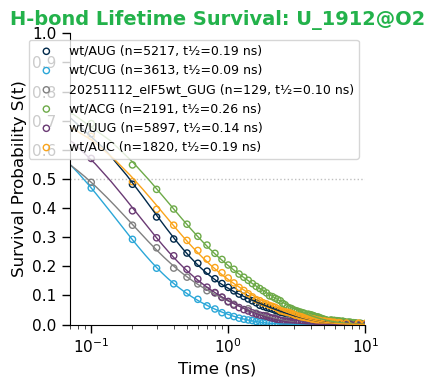

In [309]:
# ============================================================
# USER SELECTION: Modify to change the comparison
# ============================================================

# Select atom to analyze
SELECTED_ATOM = 'U_1912@O2'

# Select systems (different codons, wt eIF5)
CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_GUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_AUC'
]

# ============================================================

fig = plot_survival_curves(
    all_survival_curves,
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    show_median=True,
    show_fit=True,
    figsize=(4,4)
)
#plt.show()
plt.savefig("hbond_survival_startsites.svg")

## Example 2: Compare Mutants vs Wild-Type (AUG)

Compare H-bond lifetime distributions for eIF5 mutants with AUG codon.

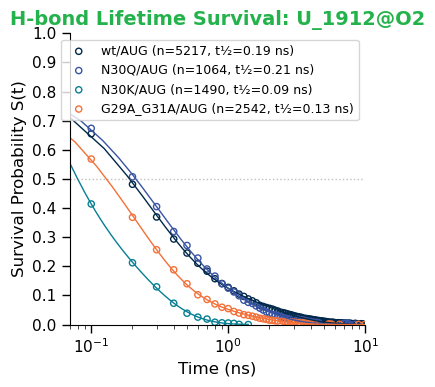

In [290]:
# ============================================================
# Compare eIF5 mutants with AUG codon
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

MUTANT_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5_N30Q_AUG',
    '20251112_eIF5_N30K_AUG',
    '20251112_eIF5_G29A_G31A_AUG'
]

# ============================================================

fig = plot_survival_curves(
    all_survival_curves,
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=MUTANT_COMPARISON_SYSTEMS,
    show_median=True,
    show_fit=True, figsize=(4,4)
)
plt.savefig("hbond_survival_eif5mutants.svg")

In [259]:
def plot_lifetime_histogram(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS,
    n_bins: int = 30,
    log_scale_y: bool = True,
    figsize: Tuple[float, float] = (4, 4)
) -> plt.Figure:
    """
    Plot lifetime distribution as horizontal histogram (density on x-axis, lifetime on y-axis).
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        time_per_frame_ns: Conversion factor (ns per frame)
        n_bins: Number of histogram bins
        log_scale_y: Whether to use log scale for y-axis (lifetime)
        figsize: Figure size as (width, height)
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Collect all lifetimes to determine bin edges
    all_lifetime_values = []
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        lifetimes_ns = np.array(all_lifetimes[system_key][selected_atom]) * time_per_frame_ns
        all_lifetime_values.extend(lifetimes_ns)
    
    if len(all_lifetime_values) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Create bin edges (log-spaced if using log scale)
    min_val = max(min(all_lifetime_values), 0.01)
    max_val = max(all_lifetime_values)
    
    if log_scale_y:
        bin_edges = np.logspace(np.log10(min_val), np.log10(max_val * 1.1), n_bins + 1)
    else:
        bin_edges = np.linspace(min_val, max_val * 1.1, n_bins + 1)
    
    # Plot each system
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        
        lifetimes = all_lifetimes[system_key][selected_atom]
        lifetimes_ns = np.array(lifetimes) * time_per_frame_ns
        n_events = len(lifetimes)
        color = SYSTEM_COLORS.get(system_key, 'gray')
        
        # Calculate histogram (density normalized)
        counts, edges = np.histogram(lifetimes_ns, bins=bin_edges, density=True)
        
        # Bin centers for plotting
        bin_centers = (edges[:-1] + edges[1:]) / 2
        
        # Filter out zero counts for cleaner plotting
        mask = counts > 0
        
        # Build label
        mean_lifetime = np.mean(lifetimes_ns)
        label = SYSTEM_LABELS.get(system_key, system_key)
        label += f" (n={n_events}, mean={mean_lifetime:.2f} ns)"
        
        # Plot scatter points (x=density, y=lifetime)
        ax.scatter(counts[mask], bin_centers[mask], color=color, s=20, 
                   label=label, edgecolor=color, facecolors='none')
        
        # Plot line connecting points
        #ax.plot(counts[mask], bin_centers[mask], color=color, linewidth=1)
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('Density', fontsize=12)
    ax.set_ylabel('Lifetime (ns)', fontsize=12)
    ax.set_title(f'H-bond Lifetime Distribution: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Set log scale for y-axis if requested
    if log_scale_y:
        ax.set_yscale('log')

    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig

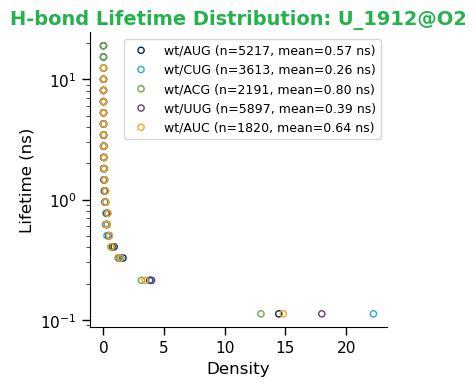

In [260]:
# ============================================================
# Histogram: Compare codons (wt eIF5)
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_AUC'
]

# ============================================================

fig = plot_lifetime_histogram(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    n_bins=25,
    log_scale_y=True,
    figsize=(4, 4)
)
plt.show()

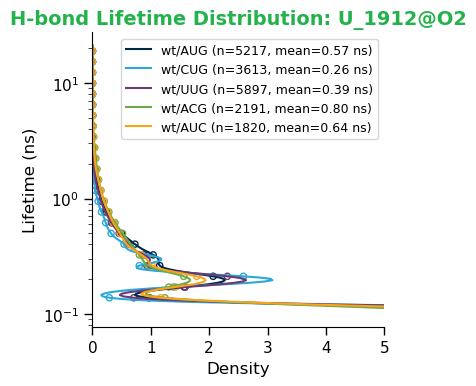

In [261]:
from scipy.stats import gaussian_kde

def plot_lifetime_kde(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS,
    log_scale_y: bool = True,
    figsize: Tuple[float, float] = (4, 4),
    bw_method: Optional[float] = None,
    n_bins: int = 25,
    show_scatter: bool = True,
    n_kde_points: int = 200
) -> plt.Figure:
    """
    Plot lifetime distribution using KDE with scatter points at bin centers.
    Both KDE line and scatter use the same density normalization.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        time_per_frame_ns: Conversion factor (ns per frame)
        log_scale_y: Whether to use log scale for y-axis (lifetime)
        figsize: Figure size as (width, height)
        bw_method: Bandwidth method for KDE (scalar multiplier, or None for default)
        n_bins: Number of histogram bins for scatter points
        show_scatter: Whether to show scatter points at bin centers
        n_kde_points: Number of points for KDE line
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Collect all lifetimes to determine common bin edges
    all_lifetime_values = []
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        lifetimes_ns = np.array(all_lifetimes[system_key][selected_atom]) * time_per_frame_ns
        all_lifetime_values.extend(lifetimes_ns)
    
    if len(all_lifetime_values) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Define range for KDE evaluation and bins
    min_val = max(min(all_lifetime_values), 0.01)
    max_val = max(all_lifetime_values)
    
    # Create bin edges (log-spaced if using log scale)
    if log_scale_y:
        bin_edges = np.logspace(np.log10(min_val), np.log10(max_val * 1.1), n_bins + 1)
        kde_y_points = np.logspace(np.log10(min_val), np.log10(max_val * 1.1), n_kde_points)
    else:
        bin_edges = np.linspace(min_val, max_val * 1.1, n_bins + 1)
        kde_y_points = np.linspace(min_val, max_val * 1.1, n_kde_points)
    
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        
        lifetimes = all_lifetimes[system_key][selected_atom]
        lifetimes_ns = np.array(lifetimes) * time_per_frame_ns
        n_events = len(lifetimes)
        color = SYSTEM_COLORS.get(system_key, 'gray')
        
        # Build label
        mean_lifetime = np.mean(lifetimes_ns)
        label = SYSTEM_LABELS.get(system_key, system_key)
        label += f" (n={n_events}, mean={mean_lifetime:.2f} ns)"
        
        # Compute KDE in log-space if using log scale (for proper density estimation)
        if log_scale_y:
            # KDE on log-transformed data
            log_lifetimes = np.log10(lifetimes_ns)
            kde = gaussian_kde(log_lifetimes, bw_method=bw_method)
            
            # Evaluate KDE at log-spaced points
            log_kde_points = np.log10(kde_y_points)
            kde_density = kde(log_kde_points)
            
            # Transform density back: f(y) = f(log(y)) / (y * ln(10))
            # This accounts for the Jacobian of the log transform
            kde_density_transformed = kde_density / (kde_y_points * np.log(10))
            
            # Plot KDE line
            ax.plot(kde_density_transformed, kde_y_points, color=color, linewidth=1.5, label=label)
            
            # Scatter points: evaluate KDE at bin centers
            if show_scatter:
                bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # Geometric mean for log bins
                log_bin_centers = np.log10(bin_centers)
                scatter_density = kde(log_bin_centers) / (bin_centers * np.log(10))
                ax.scatter(scatter_density, bin_centers, color=color, s=20,
                           edgecolor=color, facecolors='none')
        else:
            # KDE on original data
            kde = gaussian_kde(lifetimes_ns, bw_method=bw_method)
            kde_density = kde(kde_y_points)
            
            # Plot KDE line
            ax.plot(kde_density, kde_y_points, color=color, linewidth=1.5, label=label)
            
            # Scatter points: evaluate KDE at bin centers
            if show_scatter:
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                scatter_density = kde(bin_centers)
                ax.scatter(scatter_density, bin_centers, color=color, s=20,
                           edgecolor=color, facecolors='none')
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('Density', fontsize=12)
    ax.set_ylabel('Lifetime (ns)', fontsize=12)
    ax.set_title(f'H-bond Lifetime Distribution: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Set log scale for y-axis if requested
    if log_scale_y:
        ax.set_yscale('log')

    ax.set_xlim([0,5])
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig


# ============================================================
# KDE Plot: Compare codons (wt eIF5)
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_AUC',
]

fig = plot_lifetime_kde(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    log_scale_y=True,
    figsize=(4, 4),
    bw_method=0.15,
    n_bins=25,
    show_scatter=True
)
plt.show()

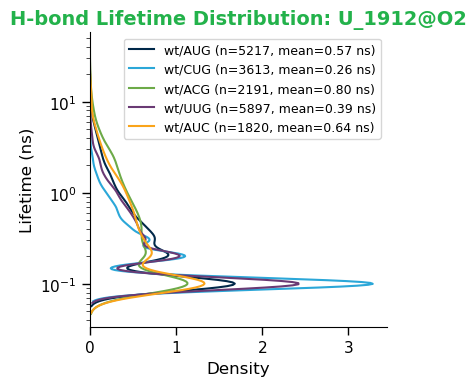

In [262]:
def plot_lifetime_kde(                                                                                         
    all_lifetimes: Dict[str, Dict[str, List[int]]],                                                            
    selected_atom: str,                                                                                        
    selected_systems: List[str],                                                                               
    time_per_frame_ns: float = TIME_PER_FRAME_NS,                                                              
    log_scale_y: bool = True,                                                                                  
    figsize: Tuple[float, float] = (4, 4),                                                                     
    bw_adjust: float = 0.5,                                                                                    
    n_bins: int = 25,                                                                                          
    show_scatter: bool = True                                                                                  
) -> plt.Figure:                                                                                               
    """                                                                                                        
    Plot lifetime distribution using seaborn KDE with scatter points at b                                      
in centers.                                                                                                    
                                                                                                               
    Args:                                                                                                      
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)                                        
        selected_atom: Atom to plot                                                                            
        selected_systems: Systems to include                                                                   
        time_per_frame_ns: Conversion factor (ns per frame)                                                    
        log_scale_y: Whether to use log scale for y-axis (lifetime)                                            
        figsize: Figure size as (width, height)                                                                
        bw_adjust: Bandwidth adjustment for KDE (smaller = more detail)                                        
        n_bins: Number of histogram bins for scatter points                                                    
        show_scatter: Whether to show scatter points at bin centers                                            
                                                                                                               
    Returns:                                                                                                   
        matplotlib Figure                                                                                      
    """                                                                                                        
    fig, ax = plt.subplots(figsize=figsize)                                                                    
                                                                                                               
    # Collect all lifetimes to determine common bin edges for scatter                                          
    all_lifetime_values = []                                                                                   
    for system_key in selected_systems:                                                                        
        if system_key not in all_lifetimes:                                                                    
            continue                                                                                           
        if selected_atom not in all_lifetimes[system_key]:                                                     
            continue                                                                                           
        lifetimes_ns = np.array(all_lifetimes[system_key][selected_atom])* time_per_frame_ns                                                                                           
        all_lifetime_values.extend(lifetimes_ns)                                                               
                                                                                                               
    if len(all_lifetime_values) == 0:                                                                          
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center',transform=ax.transAxes)                                                                                        
        return fig                                                                                             
                                                                                                               
    # Create common bin edges for scatter points                                                               
    min_val = max(min(all_lifetime_values), 0.01)                                                              
    max_val = max(all_lifetime_values)                                                                         
                                                                                                               
    if log_scale_y:                                                                                            
        bin_edges = np.logspace(np.log10(min_val), np.log10(max_val * 1.1), n_bins + 1)                                                                                                 
    else:                                                                                                      
        bin_edges = np.linspace(min_val, max_val * 1.1, n_bins + 1)                                            
                                                                                                               
    for system_key in selected_systems:                                                                        
        if system_key not in all_lifetimes:                                                                    
            continue                                                                                           
        if selected_atom not in all_lifetimes[system_key]:                                                     
            continue                                                                                           
                                                                                                               
        lifetimes = all_lifetimes[system_key][selected_atom]                                                   
        lifetimes_ns = np.array(lifetimes) * time_per_frame_ns                                                 
        n_events = len(lifetimes)                                                                              
        color = SYSTEM_COLORS.get(system_key, 'gray')                                                          
                                                                                                               
        # Build label                                                                                          
        mean_lifetime = np.mean(lifetimes_ns)                                                                  
        label = SYSTEM_LABELS.get(system_key, system_key)                                                      
        label += f" (n={n_events}, mean={mean_lifetime:.2f} ns)"                                               
                                                                                                               
        # Plot KDE                                                                                             
        if log_scale_y:                                                                                        
            sns.kdeplot(                                                                                       
                y=lifetimes_ns,                                                                                
                ax=ax,                                                                                         
                color=color,                                                                                   
                label=label,                                                                                   
                linewidth=1.5,                                                                                 
                bw_adjust=bw_adjust,                                                                           
                log_scale=(False, True),                                                                       
                fill=False                                                                                     
            )                                                                                                  
        else:                                                                                                  
            sns.kdeplot(                                                                                       
                y=lifetimes_ns,                                                                                
                ax=ax,                                                                                         
                color=color,                                                                                   
                label=label,                                                                                   
                linewidth=1.5,                                                                                 
                bw_adjust=bw_adjust,                                                                           
                fill=False                                                                                     
            )                                                                                                  
                                                                                                               
        # Add scatter points at histogram bin centers                                                          
        if show_scatter:                                                                                       
            counts, edges = np.histogram(lifetimes_ns, bins=bin_edges, density=True)                                                                                                     
            bin_centers = (edges[:-1] + edges[1:]) / 2                                                         
            mask = counts > 0                                                                                  
                                                                                                               
            ax.scatter(counts[mask], bin_centers[mask], color=color, s=20,                                                                                                              
                       edgecolor=color, facecolors='none')                                                     
                                                                                                               
    # Get molecule group for title coloring                                                                    
    group = get_molecule_group(selected_atom, '20251112')                                                      
    title_color = GROUP_COLORS.get(group, 'black')                                                             
                                                                                                               
    ax.set_xlabel('Density', fontsize=12)                                                                      
    ax.set_ylabel('Lifetime (ns)', fontsize=12)                                                                
    ax.set_title(f'H-bond Lifetime Distribution: {selected_atom}',                                             
                fontsize=14, fontweight='bold', color=title_color)                                             
                                                                                                               
    # Remove grid lines                                                                                        
    ax.grid(False)                                                                                             
                                                                                                               
    # Remove top and right spines                                                                              
    ax.spines['top'].set_visible(False)                                                                        
    ax.spines['right'].set_visible(False)                                                                      
                                                                                                               
    # Tick marks on outside                                                                                    
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)                                                                                                      
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)                                                                                                    
                                                                                                               
    ax.legend(loc='upper right', fontsize=9)                                                                   
                                                                                                               
    plt.tight_layout()                                                                                         
    return fig                                                                                                 
                                                                                                               
                                                                                                               
# ============================================================                                                 
# KDE Plot: Compare codons (wt eIF5)                                                                           
# ============================================================                                                 
                                                                                                               
SELECTED_ATOM = 'U_1912@O2'                                                                                    
                                                                                                               
CODON_COMPARISON_SYSTEMS = [                                                                                   
    '20251112_eIF5wt_AUG',                                                                                     
    '20251112_eIF5wt_CUG',                                                                                     
    '20251112_eIF5wt_ACG',                                                                                     
    '20251112_eIF5wt_UUG',                                                                                     
    '20251112_eIF5wt_AUC'                                                                                      
]                                                                                                              
                                                                                                               
fig = plot_lifetime_kde(                                                                                       
    all_lifetimes,                                                                                             
    selected_atom=SELECTED_ATOM,                                                                               
    selected_systems=CODON_COMPARISON_SYSTEMS,                                                                 
    log_scale_y=True,                                                                                          
    figsize=(4, 4),                                                                                            
    bw_adjust=1,                                                                                               
    n_bins=25,                                                                                                 
    show_scatter=False                                                                                          
)                                                                                                              
plt.show()                                                                                                     

## Boxplot

### Visualization functions

In [281]:
def prepare_lifetime_dataframe(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> pd.DataFrame:
    """
    Prepare a DataFrame of lifetimes for boxplot/violin visualization.
    
    Pools all clones per system into a single DataFrame.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to include
        selected_systems: Systems to include
        time_per_frame_ns: Conversion factor (ns per frame)
    
    Returns:
        DataFrame with columns: System, System_Label, Lifetime_ns
    """
    rows: List[Dict] = []
    
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        
        lifetimes = all_lifetimes[system_key][selected_atom]
        label = SYSTEM_LABELS.get(system_key, system_key)
        
        for lifetime_frames in lifetimes:
            rows.append({
                'System': system_key,
                'System_Label': label,
                'Lifetime_ns': lifetime_frames * time_per_frame_ns
            })
    
    df = pd.DataFrame(rows)
    
    # Preserve order of systems as provided
    if len(df) > 0:
        label_order = [SYSTEM_LABELS.get(s, s) for s in selected_systems 
                       if s in all_lifetimes and selected_atom in all_lifetimes.get(s, {})]
        df['System_Label'] = pd.Categorical(df['System_Label'], categories=label_order, ordered=True)
    
    return df


def get_system_statistics(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> Dict[str, Dict[str, float]]:
    """
    Calculate statistics for legend display.
    
    Returns:
        Dict[system_key] -> {'n_events': int, 'mean': float}
    """
    stats: Dict[str, Dict[str, float]] = {}
    
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        
        lifetimes = all_lifetimes[system_key][selected_atom]
        lifetimes_ns = np.array(lifetimes) * time_per_frame_ns
        
        stats[system_key] = {
            'n_events': len(lifetimes),
            'mean': np.mean(lifetimes_ns) if len(lifetimes) > 0 else 0.0
        }
    
    return stats


def plot_lifetime_boxplot(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS,
    log_scale_y: bool = True,
    figsize: Tuple[float, float] = (6, 5),
    jitter_size: float = 3,
    jitter_alpha: float = 0.4,
    show_jitter: bool = True
) -> plt.Figure:
    """
    Plot lifetime distribution as boxplot with optional jitter overlay.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        time_per_frame_ns: Conversion factor (ns per frame)
        log_scale_y: Whether to use log scale for y-axis (lifetime)
        figsize: Figure size as (width, height)
        jitter_size: Size of jitter points
        jitter_alpha: Alpha transparency of jitter points
        show_jitter: Whether to show jitter points overlay
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data
    df = prepare_lifetime_dataframe(all_lifetimes, selected_atom, selected_systems, time_per_frame_ns)
    
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Get statistics for legend
    stats = get_system_statistics(all_lifetimes, selected_atom, selected_systems, time_per_frame_ns)
    
    # Create color palette for systems
    palette = {SYSTEM_LABELS.get(s, s): SYSTEM_COLORS.get(s, 'gray') for s in selected_systems}
    
    # Plot boxplot
    # sns.boxplot(
    #     data=df,
    #     x='System_Label',
    #     y='Lifetime_ns',
    #     ax=ax,
    #     palette=palette,
    #     linewidth=1.5,
    #     fliersize=0  # Hide outliers (will show with jitter)
    # )
    
    # Add jitter overlay
    if show_jitter:
        sns.stripplot(
            data=df,
            x='System_Label',
            y='Lifetime_ns',
            ax=ax,
            palette=palette,
            size=jitter_size,
            alpha=jitter_alpha,
            jitter=0.25
        )
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('System', fontsize=12)
    ax.set_ylabel('Lifetime (ns)', fontsize=12)
    ax.set_title(f'H-bond Lifetime Distribution: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Set log scale for y-axis if requested
    if log_scale_y:
        ax.set_yscale('log')
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    ax.tick_params(axis='x', rotation=45)
    
    # Create custom legend with statistics
    legend_handles = []
    for system_key in selected_systems:
        if system_key not in stats:
            continue
        color = SYSTEM_COLORS.get(system_key, 'gray')
        label = SYSTEM_LABELS.get(system_key, system_key)
        s = stats[system_key]
        legend_label = f"{label} (n={s['n_events']}, mean={s['mean']:.2f} ns)"
        handle = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color,
                           markersize=8, label=legend_label)
        legend_handles.append(handle)
    
    ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig

### Plot codon comparison boxplot

/tmp/ipykernel_268193/463755482.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


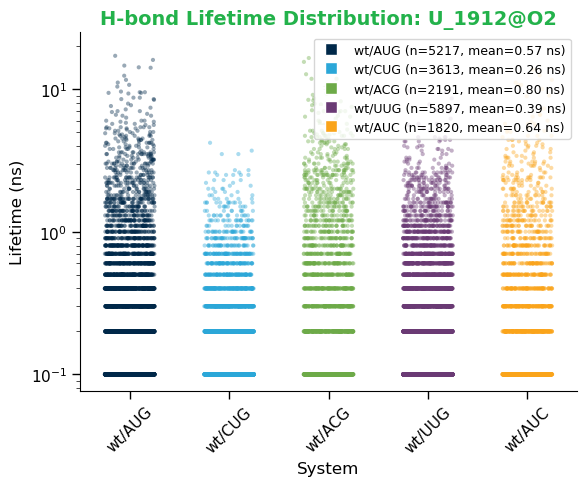

In [282]:
# ============================================================
# Example: Boxplot with jitter - Compare codons (wt eIF5)
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_AUC'
]

# Boxplot with jitter overlay
fig = plot_lifetime_boxplot(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    log_scale_y=True,
    figsize=(6, 5),
    jitter_size=3,
    jitter_alpha=0.4,
    show_jitter=True
)
plt.show()

## Violin plot

### Distribution Comparison Metrics

To quantitatively compare lifetime distributions between systems, we use two complementary statistical measures. All comparisons are made against the **wt/AUG** reference system.

**Kolmogorov-Smirnov (KS) Test:**
- Non-parametric test comparing two empirical distributions
- Measures the maximum absolute difference between cumulative distribution functions (CDFs)
- **KS statistic**: Ranges 0-1, where 0 = identical distributions, 1 = completely different
- **p-value**: Probability of observing this difference if distributions were identical; p < 0.05 suggests statistically significant difference

**Jensen-Shannon (JS) Divergence:**
- Symmetric measure of similarity between two probability distributions
- Based on Kullback-Leibler divergence but symmetric and bounded
- Ranges 0-1 (using log base 2), where 0 = identical, 1 = maximally different
- More robust than KS for comparing distribution shapes (accounts for full distribution, not just maximum difference)
- Computed by converting lifetime data to normalized histograms

In [265]:
def compute_distribution_comparison(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    reference_system: str,
    time_per_frame_ns: float = TIME_PER_FRAME_NS,
    n_bins: int = 50
) -> pd.DataFrame:
    """
    Compute KS and Jensen-Shannon statistics comparing each system to a reference.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to analyze
        selected_systems: Systems to include
        reference_system: System to use as reference for comparisons
        time_per_frame_ns: Conversion factor (ns per frame)
        n_bins: Number of bins for histogram (used in JS calculation)
    
    Returns:
        DataFrame with columns: System, System_Label, KS_statistic, KS_pvalue, JS_divergence
    """
    results: List[Dict] = []
    
    # Get reference data
    if reference_system not in all_lifetimes or selected_atom not in all_lifetimes[reference_system]:
        raise ValueError(f"Reference system {reference_system} not found or missing atom {selected_atom}")
    
    ref_lifetimes = np.array(all_lifetimes[reference_system][selected_atom]) * time_per_frame_ns
    
    # Determine bin edges based on all data
    all_data = []
    for system_key in selected_systems:
        if system_key in all_lifetimes and selected_atom in all_lifetimes[system_key]:
            lifetimes = np.array(all_lifetimes[system_key][selected_atom]) * time_per_frame_ns
            all_data.extend(lifetimes)
    
    bin_edges = np.histogram_bin_edges(all_data, bins=n_bins)
    
    # Convert reference to histogram for JS
    ref_hist, _ = np.histogram(ref_lifetimes, bins=bin_edges, density=True)
    # Add small epsilon to avoid zeros
    ref_hist = ref_hist + 1e-10
    ref_hist = ref_hist / ref_hist.sum()
    
    for system_key in selected_systems:
        if system_key not in all_lifetimes:
            continue
        if selected_atom not in all_lifetimes[system_key]:
            continue
        
        label = SYSTEM_LABELS.get(system_key, system_key)
        lifetimes = np.array(all_lifetimes[system_key][selected_atom]) * time_per_frame_ns
        
        if system_key == reference_system:
            # Reference system: show zeros
            results.append({
                'System': system_key,
                'System_Label': label,
                'KS_statistic': 0.0,
                'KS_pvalue': 1.0,
                'JS_divergence': 0.0
            })
        else:
            # KS test
            ks_stat, ks_pval = stats.ks_2samp(ref_lifetimes, lifetimes)
            
            # JS divergence
            test_hist, _ = np.histogram(lifetimes, bins=bin_edges, density=True)
            test_hist = test_hist + 1e-10
            test_hist = test_hist / test_hist.sum()
            js_div = jensenshannon(ref_hist, test_hist, base=2)
            
            results.append({
                'System': system_key,
                'System_Label': label,
                'KS_statistic': ks_stat,
                'KS_pvalue': ks_pval,
                'JS_divergence': js_div
            })
    
    return pd.DataFrame(results)

In [266]:
def plot_lifetime_violin(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    time_per_frame_ns: float = TIME_PER_FRAME_NS,
    log_scale_y: bool = True,
    figsize: Tuple[float, float] = (6, 5),
    inner: str = 'box'
) -> plt.Figure:
    """
    Plot lifetime distribution as violin plot.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        time_per_frame_ns: Conversion factor (ns per frame)
        log_scale_y: Whether to use log scale for y-axis (lifetime)
        figsize: Figure size as (width, height)
        inner: Violin inner display ('box', 'quartiles', 'point', 'stick', None)
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data
    df = prepare_lifetime_dataframe(all_lifetimes, selected_atom, selected_systems, time_per_frame_ns)
    
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Get statistics for legend
    stats = get_system_statistics(all_lifetimes, selected_atom, selected_systems, time_per_frame_ns)
    
    # Create color palette for systems
    palette = {SYSTEM_LABELS.get(s, s): SYSTEM_COLORS.get(s, 'gray') for s in selected_systems}
    
    # For log scale, transform data before violin plot and adjust ticks
    if log_scale_y:
        df['Lifetime_log'] = np.log10(df['Lifetime_ns'])
        
        sns.violinplot(
            data=df,
            x='System_Label',
            y='Lifetime_log',
            ax=ax,
            palette=palette,
            linewidth=1.5,
            inner=inner,
            cut=2
        )
        
        # Set y-axis to show original values
        y_min, y_max = ax.get_ylim()
        tick_locs = np.arange(np.floor(y_min), np.ceil(y_max) + 1)
        ax.set_yticks(tick_locs)
        ax.set_yticklabels([f'{10**t:.1g}' for t in tick_locs])
        ax.set_ylabel('Lifetime (ns)', fontsize=12)
    else:
        sns.violinplot(
            data=df,
            x='System_Label',
            y='Lifetime_ns',
            ax=ax,
            palette=palette,
            linewidth=1.5,
            inner=inner,
            cut=2
        )
        ax.set_ylabel('Lifetime (ns)', fontsize=12)
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('System', fontsize=12)
    ax.set_title(f'H-bond Lifetime Distribution: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    ax.tick_params(axis='x', rotation=45)
    
    # Create custom legend with statistics
    legend_handles = []
    for system_key in selected_systems:
        if system_key not in stats:
            continue
        color = SYSTEM_COLORS.get(system_key, 'gray')
        label = SYSTEM_LABELS.get(system_key, system_key)
        s = stats[system_key]
        legend_label = f"{label} (n={s['n_events']}, mean={s['mean']:.2f} ns)"
        handle = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color,
                           markersize=8, label=legend_label)
        legend_handles.append(handle)
    
    ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig

/tmp/ipykernel_268193/1408054846.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


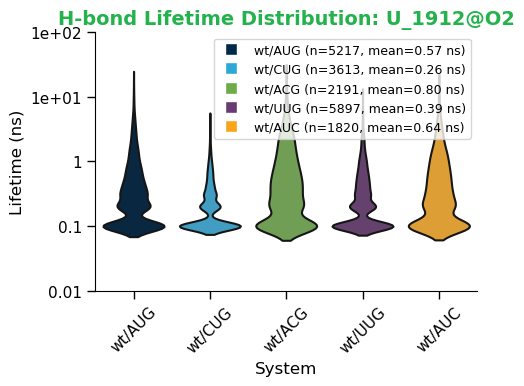


Distribution comparison vs wt/AUG (reference):


,System_Label,KS_statistic,KS_pvalue,JS_divergence
0,wt/AUG,0.000,1.00e+00,0.000
1,wt/CUG,0.189,3.18e-67,0.194
2,wt/ACG,0.103,1.07e-14,0.118
3,wt/UUG,0.091,1.82e-20,0.099
4,wt/AUC,0.048,4.30e-03,0.080


In [285]:
# ============================================================
# Example: Violin plot - Compare codons (wt eIF5)
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_AUC'
]

# Violin plot
fig = plot_lifetime_violin(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    log_scale_y=True,
    figsize=(5, 4),
    inner=None  # Options: 'box', 'quartiles', 'point', 'stick', None
)
plt.show()

# Compute and display distribution comparison statistics
comparison_df = compute_distribution_comparison(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    reference_system='20251112_eIF5wt_AUG'
)

print("\nDistribution comparison vs wt/AUG (reference):")
display(comparison_df[['System_Label', 'KS_statistic', 'KS_pvalue', 'JS_divergence']].style.format({
    'KS_statistic': '{:.3f}',
    'KS_pvalue': '{:.2e}',
    'JS_divergence': '{:.3f}'
}))

/tmp/ipykernel_268193/1408054846.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


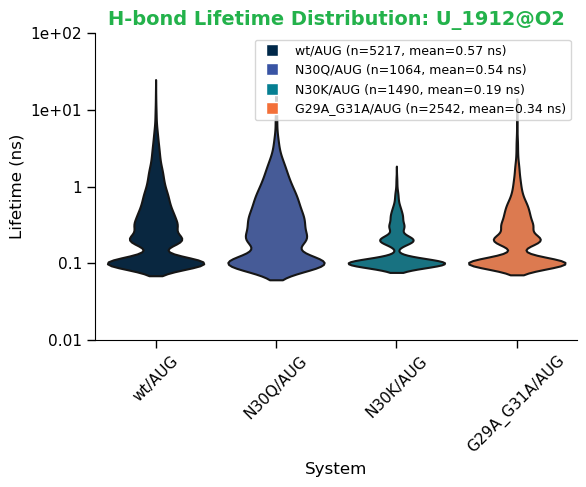


Distribution comparison vs wt/AUG (reference):


,System_Label,KS_statistic,KS_pvalue,JS_divergence
0,wt/AUG,0.000,1.00e+00,0.000
1,N30Q/AUG,0.036,2.04e-01,0.106
2,N30K/AUG,0.270,1.08e-74,0.287
3,G29A_G31A/AUG,0.113,1.26e-19,0.143


In [268]:
# ============================================================
# Example: Violin plot - Compare mutants vs wild-type (AUG)
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

MUTANT_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5_N30Q_AUG',
    '20251112_eIF5_N30K_AUG',
    '20251112_eIF5_G29A_G31A_AUG'
]

# Violin plot
fig = plot_lifetime_violin(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=MUTANT_COMPARISON_SYSTEMS,
    log_scale_y=True,
    figsize=(6, 5),
    inner=None  # Options: 'box', 'quartiles', 'point', 'stick', None
)
plt.show()

# Compute and display distribution comparison statistics
comparison_df = compute_distribution_comparison(
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=MUTANT_COMPARISON_SYSTEMS,
    reference_system='20251112_eIF5wt_AUG'
)

print("\nDistribution comparison vs wt/AUG (reference):")
display(comparison_df[['System_Label', 'KS_statistic', 'KS_pvalue', 'JS_divergence']].style.format({
    'KS_statistic': '{:.3f}',
    'KS_pvalue': '{:.2e}',
    'JS_divergence': '{:.3f}'
}))

## Summary Statistics Table

Median lifetime, mean lifetime, and number of events per system/atom.

In [83]:
def calculate_lifetime_statistics(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    all_survival_curves: Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> pd.DataFrame:
    """
    Calculate summary statistics for all system-atom combinations.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        all_survival_curves: Dict[system][atom] -> (time_pts, survival)
        time_per_frame_ns: Conversion factor
    
    Returns:
        DataFrame with summary statistics
    """
    rows: List[Dict] = []
    
    for system_key in sorted(all_lifetimes.keys()):
        parts = system_key.split('_')
        date = parts[0]
        variant = '_'.join(parts[1:-1])
        codon = parts[-1]
        
        for atom_name, lifetimes in all_lifetimes[system_key].items():
            if len(lifetimes) == 0:
                continue
            
            lifetimes_ns = np.array(lifetimes) * time_per_frame_ns
            
            # Get survival curve for median
            time_pts, surv_prob = all_survival_curves[system_key][atom_name]
            median = find_median_lifetime(time_pts, surv_prob)
            
            group = get_molecule_group(atom_name, date)
            res_num = extract_residue_number(atom_name)
            
            rows.append({
                'Date': date,
                'Variant': variant,
                'Codon': codon,
                'System': SYSTEM_LABELS.get(system_key, system_key),
                'Atom': atom_name,
                'Residue': res_num,
                'Group': group,
                'N_Events': len(lifetimes),
                'Mean_Lifetime_ns': np.mean(lifetimes_ns),
                'Std_Lifetime_ns': np.std(lifetimes_ns),
                'Median_Lifetime_ns': median if median is not None else np.nan,
                'Min_Lifetime_ns': np.min(lifetimes_ns),
                'Max_Lifetime_ns': np.max(lifetimes_ns)
            })
    
    df = pd.DataFrame(rows)
    df = df.sort_values(['Date', 'Variant', 'Codon', 'Group', 'Residue', 'Atom'])
    return df


summary_df = calculate_lifetime_statistics(all_lifetimes, all_survival_curves)
print(f"Total rows: {len(summary_df)}")
print(f"\nLifetime Statistics Summary:")
display(summary_df)

Total rows: 530

Lifetime Statistics Summary:


,Date,Variant,Codon,System,Atom,Residue,Group,N_Events,Mean_Lifetime_ns,Std_Lifetime_ns,Median_Lifetime_ns,Min_Lifetime_ns,Max_Lifetime_ns
58,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,LYS_844@HB3,844,eIF5,1,0.100000,0.000000e+00,0.050000,0.1,0.1
33,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,LYS_844@O,844,eIF5,51,0.207843,1.968807e-01,0.082258,0.1,1.0
0,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,ALA_845@C,845,eIF5,106,0.106604,2.483480e-02,0.053535,0.1,0.2
1,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,ALA_845@HB1,845,eIF5,27,0.100000,1.387779e-17,0.050000,0.1,0.1
2,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,ALA_845@HB2,845,eIF5,26,0.100000,1.387779e-17,0.050000,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,20251112,eIF5wt,UUG,wt/UUG,A_1913@HO2',1913,tRNAi,100,0.113000,4.160529e-02,0.056180,0.1,0.4
486,20251112,eIF5wt,UUG,wt/UUG,A_1913@N3,1913,tRNAi,41,0.131707,5.604451e-02,0.068333,0.1,0.3
487,20251112,eIF5wt,UUG,wt/UUG,A_1913@O2',1913,tRNAi,184,0.318478,4.362462e-01,0.120588,0.1,3.7
488,20251112,eIF5wt,UUG,wt/UUG,A_1913@O4',1913,tRNAi,609,0.111330,3.695785e-02,0.055364,0.1,0.4


In [86]:
summary_df[summary_df['Atom'] == 'U_1912@O2']

,Date,Variant,Codon,System,Atom,Residue,Group,N_Events,Mean_Lifetime_ns,Std_Lifetime_ns,Median_Lifetime_ns,Min_Lifetime_ns,Max_Lifetime_ns
39,20251112,eIF5_G29A_G31A,AUG,G29A_G31A/AUG,U_1912@O2,1912,tRNAi,2542,0.341109,0.552910,0.134185,0.1,9.9
85,20251112,eIF5_N30K,AUG,N30K/AUG,U_1912@O2,1912,tRNAi,1490,0.193691,0.162779,0.085338,0.1,1.4
157,20251112,eIF5_N30Q,AUG,N30Q/AUG,U_1912@O2,1912,tRNAi,1064,0.535902,0.856920,0.207339,0.1,11.1
250,20251112,eIF5wt,ACG,wt/ACG,U_1912@O2,1912,tRNAi,2191,0.802875,1.409742,0.257337,0.1,19.2
318,20251112,eIF5wt,AUC,wt/AUC,U_1912@O2,1912,tRNAi,1820,0.636813,1.141041,0.193993,0.1,13.7
371,20251112,eIF5wt,AUG,wt/AUG,U_1912@O2,1912,tRNAi,5217,0.574832,1.082590,0.189436,0.1,17.1
433,20251112,eIF5wt,CUG,wt/CUG,U_1912@O2,1912,tRNAi,3613,0.264960,0.329315,0.094138,0.1,4.2
496,20251112,eIF5wt,UUG,wt/UUG,U_1912@O2,1912,tRNAi,5897,0.392454,0.597175,0.139161,0.1,9.7


In [23]:
# Export summary to CSV
output_path = Path('../data/hbond_lifetime_summary.csv')
summary_df.to_csv(output_path, index=False)
print(f"Summary exported to: {output_path}")

Summary exported to: ../data/hbond_lifetime_summary.csv
